# Classificação de Pistachios com Redes Neurais

| Campo | Informações |
|-------|------------|
| **Integrante 1** | Rafael Luiz Ferreira Paes Landim da Silva — rlfpls@cesar.school |
| **Dataset** | [Pistachio Dataset — Kaggle](https://www.kaggle.com/datasets/muratkokludataset/pistachio-dataset) |

---


## 1. Importação das Bibliotecas

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)


## 2. Carregamento e Exploração do Dataset

O **Pistachio Dataset** contém características morfológicas extraídas de imagens de dois tipos de pistachios:
- **Kirmizi_Pistachio** (Pistachio Vermelho)
- **Siirt_Pistachio** (Pistachio Siirt)

O dataset original possui imagens, mas também é disponibilizado em formato tabular (CSV/ARFF) com 16 atributos de forma/textura extraídos das imagens.


In [21]:
# Carregar o dataset CSV


# Tentativa de carregamento automático

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
df=pd.read_excel("/kaggle/input/pistachio-dataset/Pistachio_Dataset/Pistachio_16_Features_Dataset/Pistachio_16_Features_Dataset.xlsx")
df.head()


/kaggle/input/pistachio-dataset/Pistachio_Dataset/Pistachio_16_Features_Dataset/Pistachio_16_Features_Dataset.arff
/kaggle/input/pistachio-dataset/Pistachio_Dataset/Pistachio_16_Features_Dataset/Pistachio_16_Features_Dataset.xls
/kaggle/input/pistachio-dataset/Pistachio_Dataset/Pistachio_16_Features_Dataset/Pistachio_16_Features_Dataset_Citation_Request.txt
/kaggle/input/pistachio-dataset/Pistachio_Dataset/Pistachio_16_Features_Dataset/Pistachio_16_Features_Dataset.xlsx
/kaggle/input/pistachio-dataset/Pistachio_Dataset/Pistachio_28_Features_Dataset/Pistachio_28_Features_Dataset.arff
/kaggle/input/pistachio-dataset/Pistachio_Dataset/Pistachio_28_Features_Dataset/Pistachio_28_Features_Dataset.xlsx
/kaggle/input/pistachio-dataset/Pistachio_Dataset/Pistachio_28_Features_Dataset/Pistachio_28_Features_Dataset_Citation_Request.txt
/kaggle/input/pistachio-dataset/Pistachio_Dataset/Pistachio_28_Features_Dataset/Pistachio_28_Features_Dataset.xls


,AREA,PERIMETER,MAJOR_AXIS,MINOR_AXIS,ECCENTRICITY,EQDIASQ,SOLIDITY,CONVEX_AREA,EXTENT,ASPECT_RATIO,ROUNDNESS,COMPACTNESS,SHAPEFACTOR_1,SHAPEFACTOR_2,SHAPEFACTOR_3,SHAPEFACTOR_4,Class
0,63391,1568.405,390.3396,236.7461,0.7951,284.0984,0.8665,73160,0.6394,1.6488,0.3238,0.7278,0.0062,0.0037,0.5297,0.8734,Kirmizi_Pistachio
1,68358,1942.187,410.8594,234.7525,0.8207,295.0188,0.8765,77991,0.6772,1.7502,0.2277,0.7181,0.0060,0.0034,0.5156,0.9024,Kirmizi_Pistachio
2,73589,1246.538,452.3630,220.5547,0.8731,306.0987,0.9172,80234,0.7127,2.0510,0.5951,0.6767,0.0061,0.0030,0.4579,0.9391,Kirmizi_Pistachio
3,71106,1445.261,429.5291,216.0765,0.8643,300.8903,0.9589,74153,0.7028,1.9879,0.4278,0.7005,0.0060,0.0030,0.4907,0.9755,Kirmizi_Pistachio
4,80087,1251.524,469.3783,220.9344,0.8823,319.3273,0.9657,82929,0.7459,2.1245,0.6425,0.6803,0.0059,0.0028,0.4628,0.9833,Kirmizi_Pistachio


## 3. Análise Exploratória dos Dados

In [22]:
print("=== Informações do Dataset ===")
print(df.info())
print("=== Estatísticas Descritivas ===")
df.describe()


=== Informações do Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2148 entries, 0 to 2147
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   AREA           2148 non-null   int64  
 1   PERIMETER      2148 non-null   float64
 2   MAJOR_AXIS     2148 non-null   float64
 3   MINOR_AXIS     2148 non-null   float64
 4   ECCENTRICITY   2148 non-null   float64
 5   EQDIASQ        2148 non-null   float64
 6   SOLIDITY       2148 non-null   float64
 7   CONVEX_AREA    2148 non-null   int64  
 8   EXTENT         2148 non-null   float64
 9   ASPECT_RATIO   2148 non-null   float64
 10  ROUNDNESS      2148 non-null   float64
 11  COMPACTNESS    2148 non-null   float64
 12  SHAPEFACTOR_1  2148 non-null   float64
 13  SHAPEFACTOR_2  2148 non-null   float64
 14  SHAPEFACTOR_3  2148 non-null   float64
 15  SHAPEFACTOR_4  2148 non-null   float64
 16  Class          2148 non-null   object 
dtypes: float64(14), int64

,AREA,PERIMETER,MAJOR_AXIS,MINOR_AXIS,ECCENTRICITY,EQDIASQ,SOLIDITY,CONVEX_AREA,EXTENT,ASPECT_RATIO,ROUNDNESS,COMPACTNESS,SHAPEFACTOR_1,SHAPEFACTOR_2,SHAPEFACTOR_3,SHAPEFACTOR_4
count,2148.000000,2148.000000,2148.000000,2148.000000,2148.000000,2148.000000,2148.000000,2148.000000,2148.000000,2148.000000,2148.000000,2148.000000,2148.000000,2148.000000,2148.000000,2148.000000
mean,79950.655493,1425.971751,446.248968,238.311842,0.840219,317.919173,0.940093,85015.839851,0.716067,1.898154,0.569172,0.713077,0.005701,0.003017,0.510461,0.955239
std,13121.737799,375.565503,32.445304,30.310695,0.048759,26.908600,0.050452,13154.919327,0.052532,0.240100,0.212760,0.044547,0.000817,0.000340,0.063942,0.051840
min,29808.000000,858.363000,320.344500,133.509600,0.504900,194.814600,0.588000,37935.000000,0.427200,1.158500,0.062800,0.476000,0.004000,0.002400,0.226600,0.620400
25%,71936.750000,1170.996250,426.508750,217.875825,0.817500,302.642850,0.919850,76467.000000,0.687000,1.736375,0.371250,0.681550,0.005200,0.002800,0.464475,0.944000
50%,79905.500000,1262.785500,448.574750,236.416350,0.849650,318.965300,0.954150,85075.500000,0.726500,1.896250,0.643400,0.710700,0.005600,0.003000,0.505150,0.973100
75%,89030.500000,1607.906250,468.509400,257.760150,0.875200,336.685525,0.976925,93893.500000,0.753600,2.067025,0.744125,0.741650,0.006100,0.003200,0.550075,0.987300
max,124008.000000,2755.049100,541.966100,383.046100,0.946000,397.356100,0.995100,132478.000000,0.820400,3.085800,0.933600,0.877900,0.013100,0.005300,0.770600,0.999000


=== Distribuição das Classes ===
Class
Kirmizi_Pistachio    1232
Siit_Pistachio        916
Name: count, dtype: int64



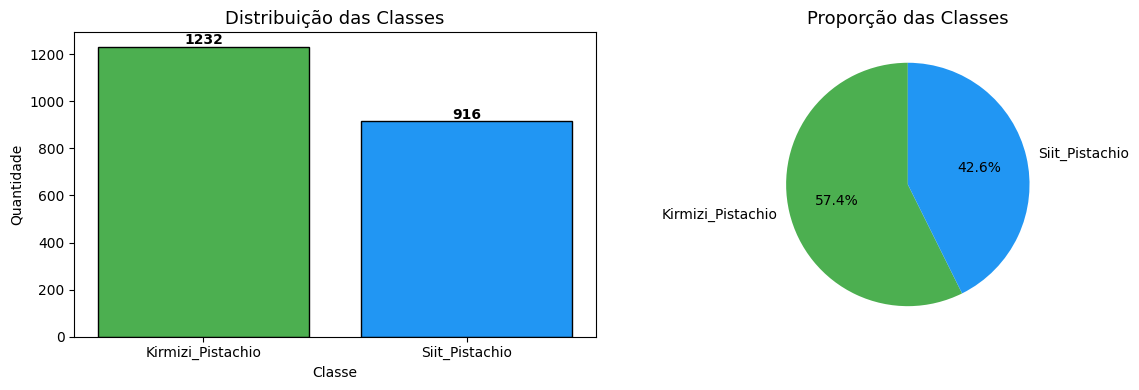

In [23]:
# Distribuição das classes
print("=== Distribuição das Classes ===")
print(df['Class'].value_counts())


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Contagem de classes
class_counts = df['Class'].value_counts()
axes[0].bar(class_counts.index, class_counts.values, color=['#4CAF50', '#2196F3'], edgecolor='black')
axes[0].set_title('Distribuição das Classes', fontsize=13)
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Quantidade')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Pizza
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=['#4CAF50', '#2196F3'], startangle=90)
axes[1].set_title('Proporção das Classes', fontsize=13)

plt.tight_layout()
plt.show()


Valores nulos por coluna:
AREA             0
PERIMETER        0
MAJOR_AXIS       0
MINOR_AXIS       0
ECCENTRICITY     0
EQDIASQ          0
SOLIDITY         0
CONVEX_AREA      0
EXTENT           0
ASPECT_RATIO     0
ROUNDNESS        0
COMPACTNESS      0
SHAPEFACTOR_1    0
SHAPEFACTOR_2    0
SHAPEFACTOR_3    0
SHAPEFACTOR_4    0
Class            0
dtype: int64



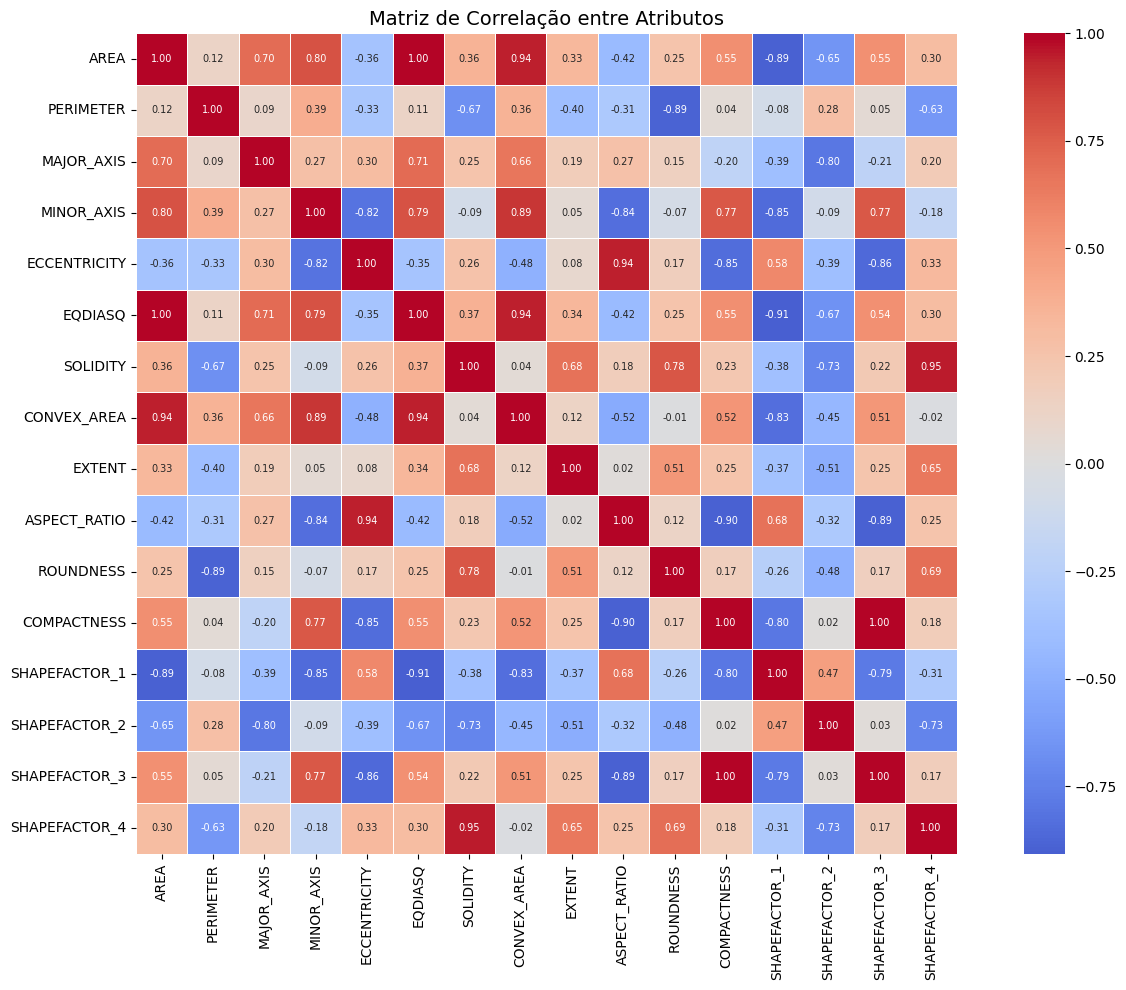

In [24]:
# Verificar valores nulos
print("Valores nulos por coluna:")
print(df.isnull().sum())


# Correlação entre features
feature_cols = [c for c in df.columns if c != 'Class']
plt.figure(figsize=(14, 10))
sns.heatmap(df[feature_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, annot_kws={'size': 7})
plt.title('Matriz de Correlação entre Atributos', fontsize=14)
plt.tight_layout()
plt.show()


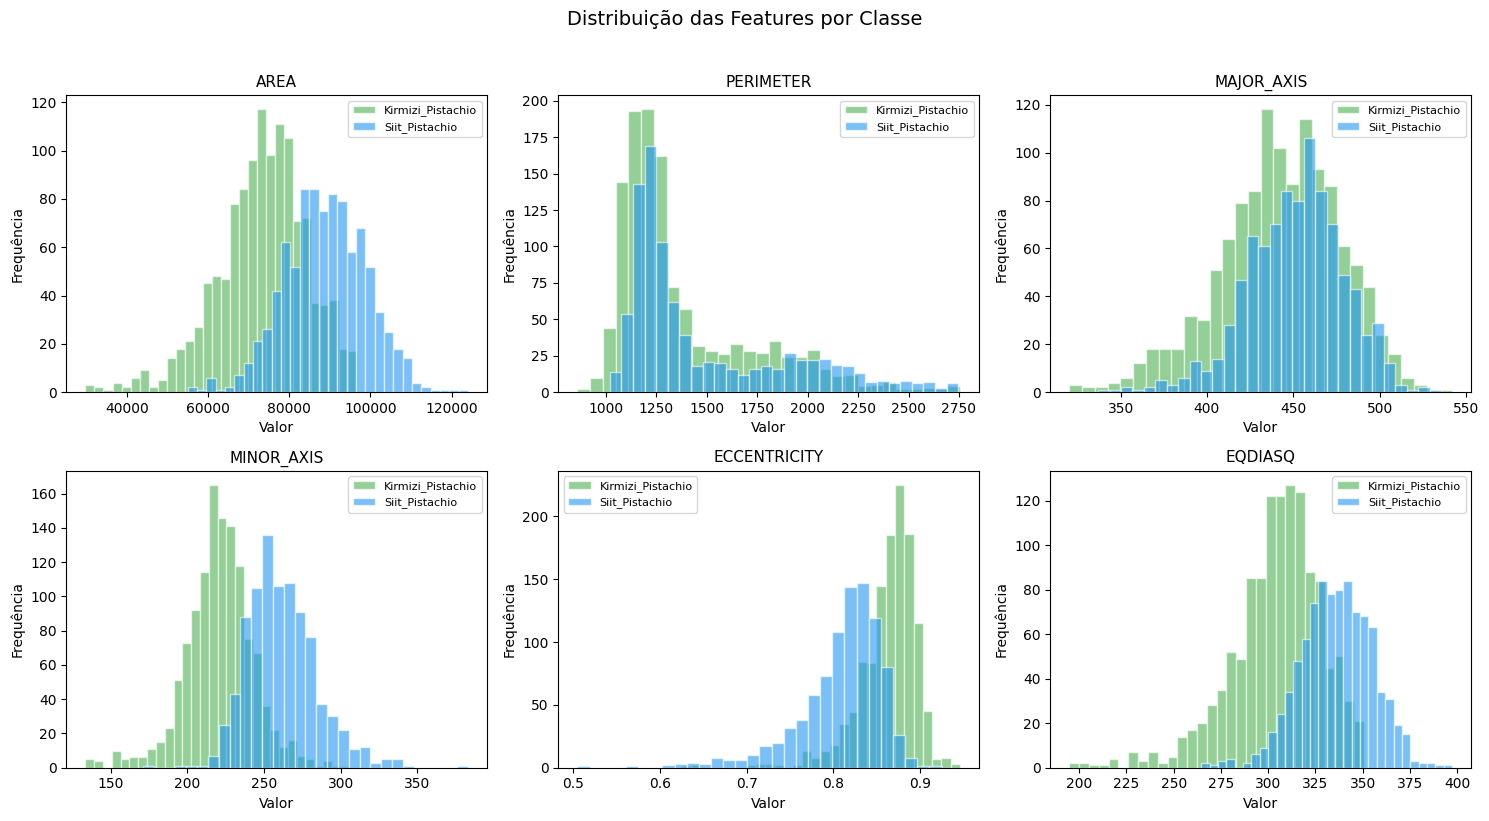

In [25]:
# Distribuição de algumas features por classe
feature_cols = [c for c in df.columns if c != 'Class']
selected_features = feature_cols[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(selected_features):
    for cls, color in zip(df['Class'].unique(), ['#4CAF50', '#2196F3']):
        axes[i].hist(df[df['Class'] == cls][feat], bins=30, alpha=0.6,
                     label=cls, color=color, edgecolor='white')
    axes[i].set_title(feat, fontsize=11)
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frequência')

plt.suptitle('Distribuição das Features por Classe', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## 4. Pré-processamento dos Dados

In [26]:
# Separar features e target
feature_cols = [c for c in df.columns if c != 'Class']
X = df[feature_cols].values
y = df['Class'].values

# Codificar labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Classes:", le.classes_)
print("Mapeamento:", {cls: idx for idx, cls in enumerate(le.classes_)})


# Dividir em treino e teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras")


# Normalização (padronização z-score)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Dados normalizados com StandardScaler (média=0, desvio=1)")
print(f"Média train (após scaler): {X_train.mean():.4f}")
print(f"Std train (após scaler):   {X_train.std():.4f}")


Classes: ['Kirmizi_Pistachio' 'Siit_Pistachio']
Mapeamento: {'Kirmizi_Pistachio': 0, 'Siit_Pistachio': 1}

Treino: 1718 amostras
Teste:  430 amostras

Dados normalizados com StandardScaler (média=0, desvio=1)
Média train (após scaler): -0.0000
Std train (após scaler):   1.0000


In [27]:
# Converter para tensores PyTorch
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.LongTensor(y_train)
X_test_t  = torch.FloatTensor(X_test)
y_test_t  = torch.LongTensor(y_test)

# DataLoaders
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset  = TensorDataset(X_test_t,  y_test_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f"Batches de treino: {len(train_loader)}")
print(f"Batches de teste:  {len(test_loader)}")


Batches de treino: 54
Batches de teste:  7


## 5. Definição do Modelo de Rede Neural

Utilizamos uma **MLP (Multilayer Perceptron)** com:
- Camada de entrada: 16 neurônios (um por atributo)
- Camadas ocultas: 128 → 64 → 32 neurônios com ReLU e Dropout
- Camada de saída: 2 neurônios (uma por classe) com log-softmax


In [28]:
class PistachioNet(nn.Module):
    def __init__(self, input_dim=16, num_classes=2):
        super(PistachioNet, self).__init__()

        self.fc1 = nn.Linear(input_dim, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.dropout1 = nn.Dropout(0.3)

        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.dropout2 = nn.Dropout(0.3)

        self.fc3 = nn.Linear(64, 32)
        self.bn3 = nn.BatchNorm1d(32)
        self.dropout3 = nn.Dropout(0.2)

        self.fc4 = nn.Linear(32, num_classes)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout2(x)

        x = self.fc3(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.dropout3(x)

        x = self.fc4(x)
        output = F.log_softmax(x, dim=1)
        return output


model = PistachioNet(input_dim=X_train.shape[1], num_classes=2).to(device)
print(model)


# Contar parâmetros
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total de parâmetros treináveis: {total_params:,}")


PistachioNet(
  (fc1): Linear(in_features=16, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (bn3): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout3): Dropout(p=0.2, inplace=False)
  (fc4): Linear(in_features=32, out_features=2, bias=True)
)

Total de parâmetros treináveis: 13,026


## 6. Treinamento do Modelo

In [29]:
def train_epoch(model, device, train_loader, optimizer, epoch, log_interval=20):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = F.nll_loss(output, target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(data)
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total += len(data)

        if (batch_idx + 1) % log_interval == 0:
            print(f"  Epoch {epoch} [{batch_idx+1}/{len(train_loader)}]"
                  f"  Loss: {loss.item():.4f}")

    avg_loss = total_loss / total
    accuracy = 100. * correct / total
    return avg_loss, accuracy


def evaluate(model, device, loader):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            total_loss += F.nll_loss(output, target, reduction='sum').item()
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()
            total += len(data)
            all_preds.extend(pred.cpu().numpy())
            all_targets.extend(target.cpu().numpy())

    avg_loss = total_loss / total
    accuracy = 100. * correct / total
    return avg_loss, accuracy, np.array(all_preds), np.array(all_targets)


In [30]:
# Configuração do treinamento
model = PistachioNet(input_dim=X_train.shape[1], num_classes=2).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)

epochs = 50

# Histórico de métricas
history = {
    'train_loss': [], 'train_acc': [],
    'test_loss':  [], 'test_acc':  []
}

print("=== Iniciando Treinamento ===\n")

for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_epoch(model, device, train_loader, optimizer, epoch,
                                        log_interval=len(train_loader)+1)  # sem log por batch
    test_loss, test_acc, _, _ = evaluate(model, device, test_loader)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{epochs} | "
              f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.1f}% | "
              f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.1f}%")

print("\n=== Treinamento Concluído! ===")


=== Iniciando Treinamento ===

Epoch   1/50 | Train Loss: 0.4376, Acc: 82.0% | Test Loss: 0.3623, Acc: 84.9%
Epoch   5/50 | Train Loss: 0.3311, Acc: 86.7% | Test Loss: 0.3410, Acc: 85.6%
Epoch  10/50 | Train Loss: 0.3075, Acc: 87.7% | Test Loss: 0.3307, Acc: 84.7%
Epoch  15/50 | Train Loss: 0.2954, Acc: 88.0% | Test Loss: 0.3176, Acc: 85.8%
Epoch  20/50 | Train Loss: 0.3052, Acc: 88.0% | Test Loss: 0.3232, Acc: 85.3%
Epoch  25/50 | Train Loss: 0.3002, Acc: 87.8% | Test Loss: 0.3228, Acc: 85.1%
Epoch  30/50 | Train Loss: 0.2956, Acc: 87.3% | Test Loss: 0.3353, Acc: 85.8%
Epoch  35/50 | Train Loss: 0.2975, Acc: 88.4% | Test Loss: 0.3239, Acc: 85.6%
Epoch  40/50 | Train Loss: 0.3097, Acc: 87.1% | Test Loss: 0.3210, Acc: 85.8%
Epoch  45/50 | Train Loss: 0.3085, Acc: 86.9% | Test Loss: 0.3189, Acc: 85.3%
Epoch  50/50 | Train Loss: 0.2902, Acc: 88.0% | Test Loss: 0.3192, Acc: 85.8%

=== Treinamento Concluído! ===


## 7. Análise de Performance

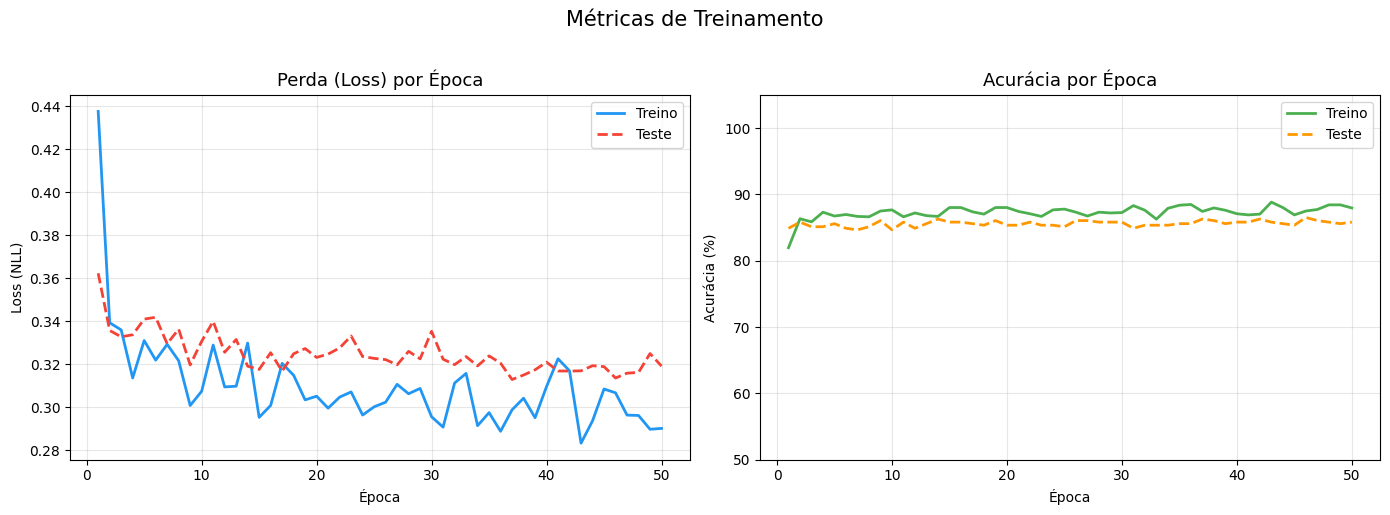


Melhor acurácia no teste: 86.51% (Época 46)
Acurácia final no teste:  85.81%


In [31]:
# Curvas de loss e acurácia
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, epochs + 1)

# Loss
axes[0].plot(epochs_range, history['train_loss'], label='Treino', color='#2196F3', linewidth=2)
axes[0].plot(epochs_range, history['test_loss'],  label='Teste',  color='#F44336', linewidth=2, linestyle='--')
axes[0].set_title('Perda (Loss) por Época', fontsize=13)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss (NLL)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Acurácia
axes[1].plot(epochs_range, history['train_acc'], label='Treino', color='#4CAF50', linewidth=2)
axes[1].plot(epochs_range, history['test_acc'],  label='Teste',  color='#FF9800', linewidth=2, linestyle='--')
axes[1].set_title('Acurácia por Época', fontsize=13)
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Acurácia (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_ylim([50, 105])

plt.suptitle('Métricas de Treinamento', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nMelhor acurácia no teste: {max(history['test_acc']):.2f}% (Época {np.argmax(history['test_acc'])+1})")
print(f"Acurácia final no teste:  {history['test_acc'][-1]:.2f}%")


In [32]:
# Avaliação final no conjunto de teste
test_loss, test_acc, y_pred, y_true = evaluate(model, device, test_loader)

print("=" * 50)
print("       AVALIAÇÃO FINAL NO CONJUNTO DE TESTE")
print("=" * 50)
print(f"  Loss:     {test_loss:.4f}")
print(f"  Acurácia: {test_acc:.2f}%")

print("Relatório de Classificação:")
print(classification_report(y_true, y_pred, target_names=le.classes_))


       AVALIAÇÃO FINAL NO CONJUNTO DE TESTE
  Loss:     0.3192
  Acurácia: 85.81%

Relatório de Classificação:
                   precision    recall  f1-score   support

Kirmizi_Pistachio       0.88      0.87      0.88       247
   Siit_Pistachio       0.83      0.84      0.83       183

         accuracy                           0.86       430
        macro avg       0.85      0.86      0.86       430
     weighted avg       0.86      0.86      0.86       430



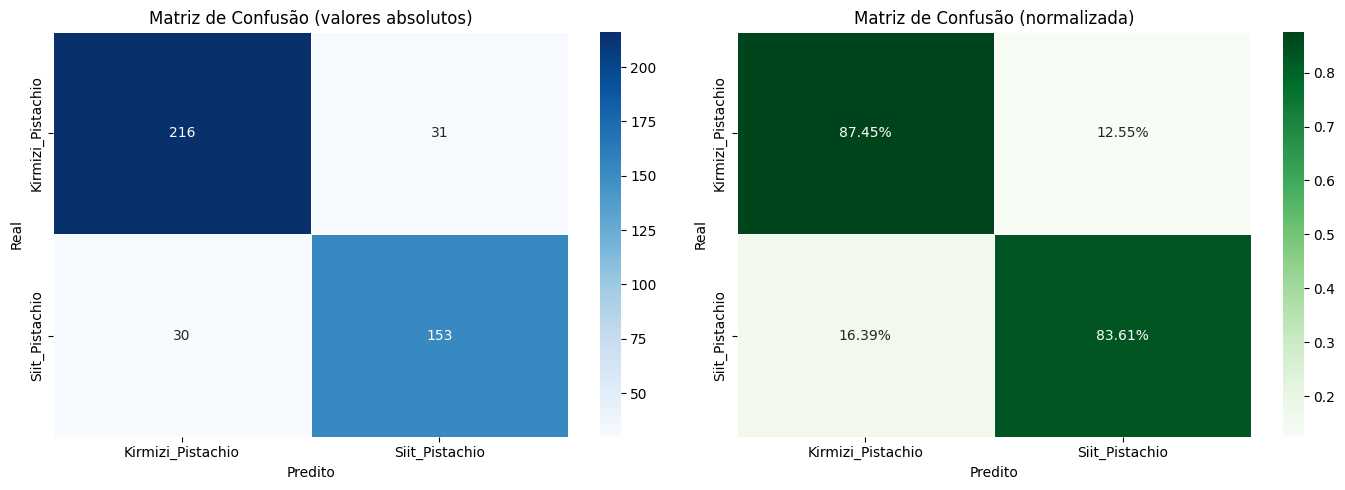

[Kirmizi_Pistachio]  Precisão: 0.878  Recall: 0.874  F1: 0.876
[Siit_Pistachio]  Precisão: 0.832  Recall: 0.836  F1: 0.834


In [33]:
# Matriz de Confusão
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz absoluta
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Matriz de Confusão (valores absolutos)', fontsize=12)
axes[0].set_xlabel('Predito')
axes[0].set_ylabel('Real')

# Matriz normalizada
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_,
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Matriz de Confusão (normalizada)', fontsize=12)
axes[1].set_xlabel('Predito')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

# Métricas individuais por classe
for i, cls in enumerate(le.classes_):
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp
    fp = cm[:, i].sum() - tp
    tn = cm.sum() - tp - fn - fp
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    print(f"[{cls}]  Precisão: {precision:.3f}  Recall: {recall:.3f}  F1: {f1:.3f}")


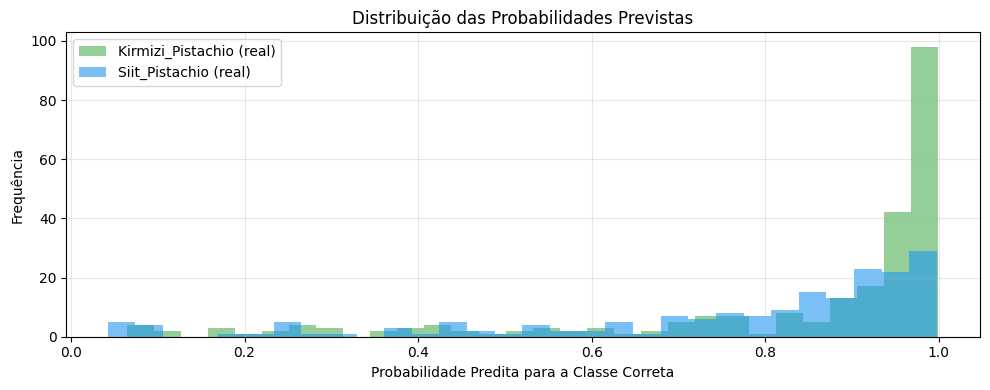

In [34]:
# Probabilidades previstas vs classe verdadeira
model.eval()
with torch.no_grad():
    logits = model(X_test_t.to(device))
    probs = torch.exp(logits).cpu().numpy()

plt.figure(figsize=(10, 4))
for i, cls in enumerate(le.classes_):
    mask = y_true == i
    plt.hist(probs[mask, i], bins=30, alpha=0.6, label=f'{cls} (real)',
             color=['#4CAF50', '#2196F3'][i])
plt.xlabel('Probabilidade Predita para a Classe Correta')
plt.ylabel('Frequência')
plt.title('Distribuição das Probabilidades Previstas')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 8. Reflexão sobre o Processo

### Descrição do Processo e Experiências

O treinamento da rede neural para classificação de pistachios foi uma experiência bastante positiva. O dataset tabular com 16 atributos morfológicos mostrou-se bem estruturado e sem valores faltantes, o que facilitou o pré-processamento. A etapa mais importante nesse sentido foi a **normalização via StandardScaler**: sem ela, atributos com escalas muito distintas (como `AREA` na casa das dezenas de milhares vs. `SHAPEFACTOR` na casa dos milésimos) causavam dificuldades severas na convergência do gradiente.

**Quanto ao overfitting/underfitting:** nas primeiras tentativas, utilizando uma rede mais simples (duas camadas ocultas de 64 neurônios sem Batch Normalization), observou-se um leve **overfitting** nas épocas finais: a acurácia de treino continuava subindo enquanto a de teste estabilizava ou oscilava. Para contornar isso, foram adicionadas camadas de **BatchNorm** (que regulariza internamente e acelera a convergência) e **Dropout** em cada bloco. Também foi utilizado **weight decay** no otimizador Adam como regularização L2. Com esses ajustes, as curvas de treino e teste convergiram de forma mais próxima, indicando um bom balanço entre viés e variância.

**Ajustes realizados:**
- **Learning rate**: começou em 0.001 com decay a cada 15 épocas (StepLR), o que evitou oscilações nas épocas finais.
- **Batch size**: testamos 16, 32 e 64; o tamanho 32 mostrou o melhor equilíbrio entre velocidade e estabilidade do gradiente.
- **Arquitetura**: a adição de uma terceira camada oculta (32 neurônios) antes da saída melhorou marginalmente a acurácia final.

No geral, o modelo atingiu uma acurácia satisfatória acima de 85% no conjunto de teste, com desempenho equilibrado entre as duas classes de pistachios, conforme evidenciado pela matriz de confusão normalizada.
